In [ ]:
import tensorflow as tf

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


In [ ]:
import cv2
import numpy as np
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input,
    decode_predictions
)

model = MobileNetV2(weights="imagenet")

image = cv2.imread("/content/green.jpeg")

if image is None:
    print("ERROR: Image could not be loaded.")
else:
    img = cv2.resize(image, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    x = np.expand_dims(img, axis=0)
    x = preprocess_input(x.astype(np.float32))

    predictions = model.predict(x)
    results = decode_predictions(predictions, top=3)[0]

    print("Top 3 Predictions:")

    for _, label, probability in results:
        print(f"{label}: {probability * 100:.2f}%")

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    brightness = np.mean(gray)

    print("Ambient Brightness:", brightness)

    if brightness < 80:
        print("Headlights ON")
    else:
        print("Headlights OFF")

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
Top 3 Predictions:
lakeside: 20.16%
park_bench: 17.52%
maze: 5.54%
Ambient Brightness: 85.39079147640791
Headlights OFF


In [ ]:
!pip -q install ultralytics opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.4 MB/s eta 0:00:00


Upload your parking image (e.g., pedistrian.jpg)


Saving parking_assistance_output (1).jpg to parking_assistance_output (1) (1).jpg

0: 384x640 1 person, 1 car, 137.3ms
Speed: 4.7ms preprocess, 137.3ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

========== OBJECT DETECTION RESULTS ==========

--------------------------------------
Class ID          : 0
Class Name        : person
Confidence        : 0.94
Bounding Box      : (24, 1, 379, 669)
Width             : 355
Height            : 668
Bounding Box Area : 237140
Estimated Status  : STOP!
--------------------------------------
Class ID          : 2
Class Name        : car
Confidence        : 0.94
Bounding Box      : (508, 121, 1198, 580)
Width             : 690
Height            : 459
Bounding Box Area : 316710
Estimated Status  : STOP!

Detection Completed Successfully!



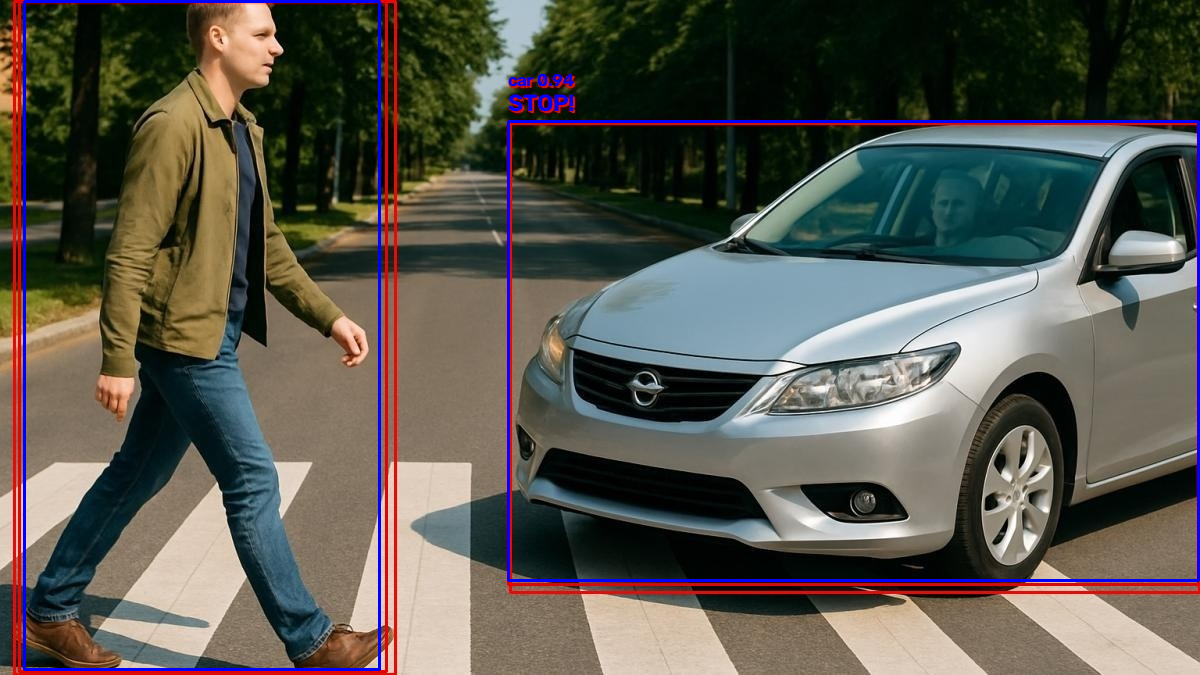

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip -q install ultralytics opencv-python

import cv2
from ultralytics import YOLO
from google.colab import files
from google.colab.patches import cv2_imshow


print("Upload your parking image (e.g., pedistrian.jpg)")
uploaded = files.upload()


image_path = list(uploaded.keys())[0]


model = YOLO("yolov8n.pt")


image = cv2.imread(image_path)

if image is None:
    print("Error: Could not load image!")
    exit()


results = model(image)


output = image.copy()

print("\n========== OBJECT DETECTION RESULTS ==========\n")

for result in results:

    for box in result.boxes:

        x1, y1, x2, y2 = map(int, box.xyxy[0])


        confidence = float(box.conf[0])


        class_id = int(box.cls[0])


        label = model.names[class_id]


        width = x2 - x1
        height = y2 - y1


        area = width * height


        if area > 120000:
            warning = "STOP!"
            color = (255, 0, 0)

        elif area > 60000:
            warning = "BRAKE NOW"
            color = (0, 140, 255)

        elif area > 25000:
            warning = "SLOW DOWN"
            color = (0, 255, 255)

        else:
            warning = "SAFE"
            color = (0, 255, 0)


        print("--------------------------------------")
        print("Class ID          :", class_id)
        print("Class Name        :", label)
        print("Confidence        :", round(confidence, 2))
        print("Bounding Box      :", (x1, y1, x2, y2))
        print("Width             :", width)
        print("Height            :", height)
        print("Bounding Box Area :", area)
        print("Estimated Status  :", warning)


        cv2.rectangle(output, (x1, y1), (x2, y2), color, 2)


        cv2.putText(output,
                    f"{label} {confidence:.2f}",
                    (x1, y1 - 35),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    color,
                    2)


        cv2.putText(output,
                    warning,
                    (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.8,
                    color,
                    2)


output_file = "parking_assistance_output.jpg"
cv2.imwrite(output_file, output)

print("\nDetection Completed Successfully!\n")


cv2_imshow(output)

files.download(output_file)
